In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [51]:
# function to get the root dir and load the data and return 4 arrays
def load_data(game_type):
    root_dir = f'../environment_simplified/outputs_deterministic_agents/{game_type}/round_wise_data/'
    # handle the error if the directory does not exist
    if not os.path.exists(root_dir):
        print('Directory does not exist')
        return []
    num_agent, steps, rounds, edge_prob = 5, 10, 2, 1
    run_spec = f'{num_agent}_{steps}_{rounds}_{edge_prob}'
    rounds_total_C_ratio = np.load(root_dir+f'rounds_total_C_ratio_{run_spec}.npy', allow_pickle=True)
    rounds_total_C_ratio_per_step = np.load(root_dir+f'rounds_total_C_ratio_per_step_{run_spec}.npy', allow_pickle=True)
    rounds_total_pair_actions = np.load(root_dir+f'rounds_total_pair_actions_{run_spec}.npy', allow_pickle=True)
    rounds_total_reward = np.load(root_dir+f'rounds_total_reward_{run_spec}.npy', allow_pickle=True)

    rounds_total_C_ratio = pd.DataFrame(rounds_total_C_ratio.tolist())
    rounds_total_C_ratio_per_step = pd.DataFrame(rounds_total_C_ratio_per_step.tolist())
    rounds_total_pair_actions = pd.DataFrame(rounds_total_pair_actions.tolist())
    rounds_total_reward = pd.DataFrame(rounds_total_reward.tolist())
    
    return [rounds_total_C_ratio, rounds_total_C_ratio_per_step, rounds_total_pair_actions, rounds_total_reward]
    

In [52]:
# define a function that gets a dataframe, and each cell is a dictionary. Return a dataframe with the sum of all dictionary values of each cell
# Replace each cell with the sum of the values of the dictionary
def sum_dicts(df):
    first_col = df.iloc[:, 0]
    result = first_col.apply(lambda x: sum(x.values()))
    return result

In [40]:
# create a dictionary to store the data, with each game_type as a key and a list of the 4 arrays as values
game_types = ['last_action', 'agent_ratio', 'network_ratio', 'RL']

all_data = {}
for game_type in game_types:
    # load C ratio, C ratio per step, pair actions, and rewards data
    all_data[game_type] = load_data(game_type)
    # add new column. calculate it like this: sum_dicts(all_data['game_type'][2])
    # This is the total number of games played in each round
    all_data[game_type].append(sum_dicts(all_data[game_type][2]))
    # now, define another column by devision of the total reward by the total number of games played, to get the average reward per game
    all_data[game_type].append(round(all_data[game_type][3].div(all_data[game_type][4], axis=0), 2))
    print(f'{game_type} data loaded')

last_action data loaded
agent_ratio data loaded
RL data loaded


In [28]:
all_data['last_action'][3][0][0]

42

In [42]:
# plot all data values [0] in the same plot
def plot_all_data(all_data, array_index, name, time_step=20, path_to_save=None, custom_y_range=False):
    for game_type in all_data.keys():
        x = range(1, time_step+1)
        y = all_data[game_type][array_index].mean(axis=0)
        std = all_data[game_type][array_index].std(axis=0)
    
        f = interp1d(x, y, kind='cubic')
        x_smooth = np.linspace(1, time_step, 100)
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=game_type)
        plt.fill_between(x, y-std, y+std, alpha=0.2)
    # change the order of plots in the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [0, 1, 2]
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')
    plt.xlabel('Step')
    plt.ylabel(f'{name}')
    plt.title(f'Evolution of {name}', fontsize=12)
    plt.xticks(np.arange(1, time_step+1, 1.0))
    if custom_y_range:
        plt.yticks(np.arange(0, 1.1, 0.1))
    # plt.savefig(os.path.join('figs/2025/', f'{name}.png'), dpi=500)
    plt.show()

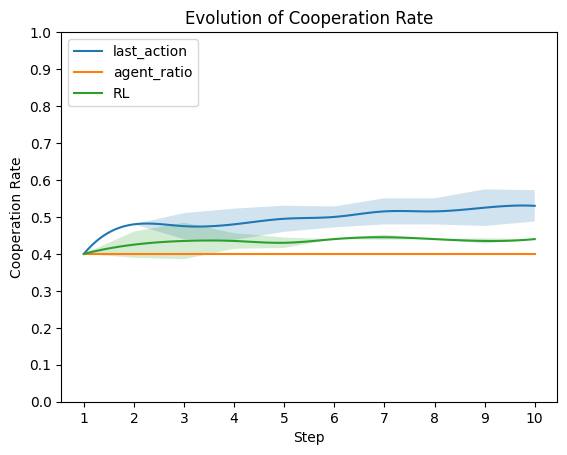

In [43]:
plot_all_data(all_data, array_index=0, name='Cooperation Rate', time_step=10, custom_y_range=True)

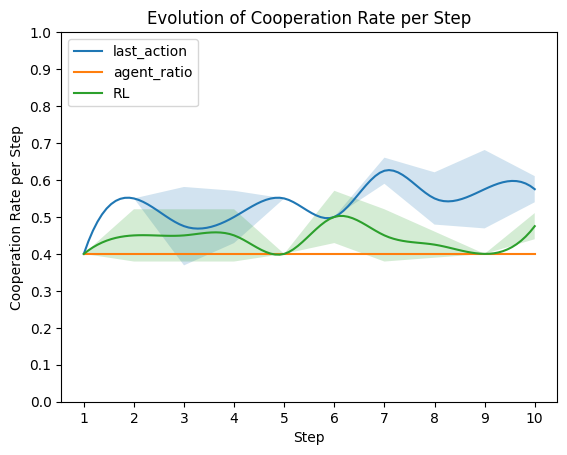

In [45]:
# do the same for all data values [1] and call it Evolution of Cooperation Rate per Step
plot_all_data(all_data, array_index=1, name='Cooperation Rate per Step', time_step=10, custom_y_range=True)

In [15]:
# print the least cooperation rate per step for network_ratio for each step
print(all_data['network_ratio'][1].min(axis=0))


0     0.00
1     0.22
2     0.00
3     0.00
4     0.00
5     0.00
6     0.00
7     0.00
8     0.00
9     0.00
10    0.00
11    0.00
12    0.00
13    0.00
14    0.00
15    0.00
16    0.00
17    0.00
18    0.00
19    0.00
dtype: float64


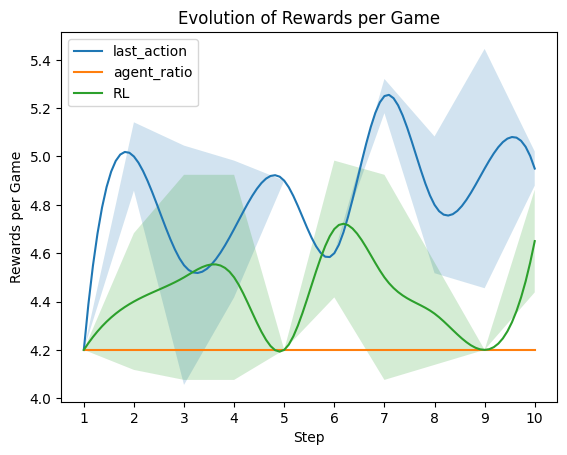

In [46]:
# plot all data values [3] in the same plot
plot_all_data(all_data, array_index=5, time_step=10, name='Rewards per Game')

In [49]:
def extract_action_values(df, action):
    """Extract values for a specific action from dictionary cells."""
    return df.applymap(lambda x: x[action]).values

def plot_pair_actions(scenario_name, pair_actions_df, time_step=20, rounds=10):
    CC = extract_action_values(pair_actions_df, 'CC')
    CD = extract_action_values(pair_actions_df, 'CD')
    DC = extract_action_values(pair_actions_df, 'DC')
    DD = extract_action_values(pair_actions_df, 'DD')
    
    # Calculate totals and means
    total_number = (CC + CD + DC + DD).sum(axis=0) / rounds
    
    # Calculate means for each action type
    CC_mean = CC.mean(axis=0) / total_number
    CD_DC_mean = (CD.mean(axis=0) + DC.mean(axis=0)) / total_number
    DD_mean = DD.mean(axis=0) / total_number
    
    # Set up plotting
    x = np.arange(1, time_step+1)
    x_smooth = np.linspace(1, time_step, 100)
    
    # Create smooth curves using vectorized operations
    actions = {
        'CC': CC_mean,
        'CD/DC': CD_DC_mean,
        'DD': DD_mean
    }
    
    plt.figure(figsize=(7, 5))
    
    # Plot each action type
    for label, values in actions.items():
        f = interp1d(x, values, kind='cubic')
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=label)
    
    # Set plot parameters
    # plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper left')
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Rate of pair choices', fontsize=13)
    plt.title(f'Evolution of LLMs pair choices - {scenario_name} scenario', fontsize=14)
    plt.xticks(np.arange(1, time_step + 1, 1.0))
    
    # Save plots
    # plt.savefig(os.path.join('figs/2025', f'pair_actions_{scenario_name}.png'), dpi=500)
    plt.show()
    plt.close()

Plotting pair actions for last_action scenario


/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_24425/4149490160.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x[action]).values


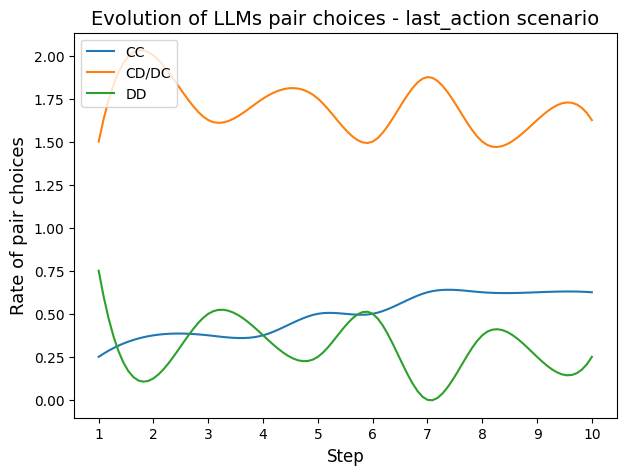

Plotting pair actions for agent_ratio scenario


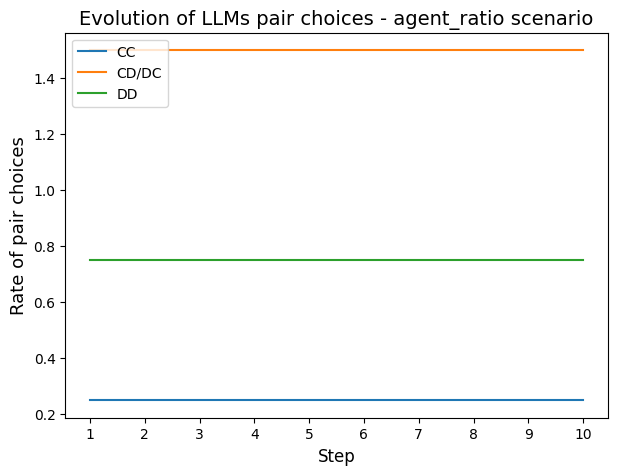

Plotting pair actions for RL scenario


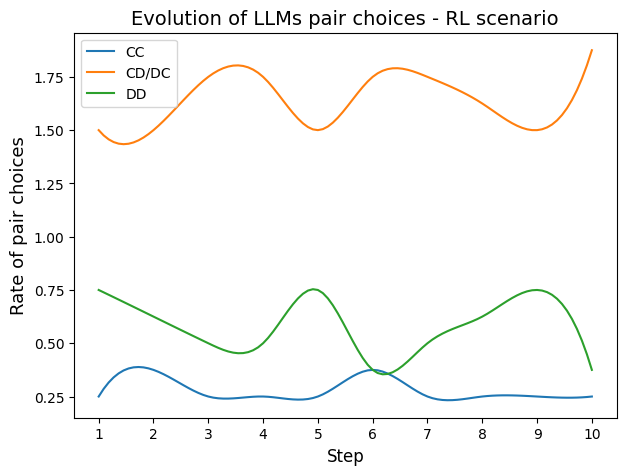

In [50]:
for game_type in game_types:
    pair_actions = all_data[game_type][2]
    # plot the pair actions
    print(f'Plotting pair actions for {game_type} scenario')
    plot_pair_actions(game_type, pair_actions, time_step=10, rounds=5)

In [19]:
# merge all four figs in /create_figures/figs/2025/ into one figure
from PIL import Image

images = [Image.open(f'figs/2025/pair_actions_{game_type}.png') for game_type in game_types]
widths, heights = zip(*(i.size for i in images))

# remove the white space around the images
images = [i.crop(i.getbbox()) for i in images]
# remove the space between the images
images = [i.crop((0, 0, i.size[0]-60, i.size[1])) for i in images]
# save the merged image to a file called 'merged.png'
total_width = max(widths) * 2 - 120
total_height = max(heights) * 2
new_im = Image.new('RGB', (total_width, total_height))

# top row
new_im.paste(images[0], (0, 0))  # RL
new_im.paste(images[1], (max(widths)-60, 0))  # NR

# bottom row
new_im.paste(images[2], (0, max(heights)))  # LA
new_im.paste(images[3], (max(widths)-60, max(heights)))  # AR

# new_im.save('figs/2025/merged_pair_actions.png', dpi=(300, 300))

# show the merged image
new_im.show()

In [20]:
# load the npy files in the following dir
# ../environment_simplified/outputs/last_action/round_wise_data/rounds_total_C_ratio_per_step_20_20_10_0.25_nun2.npy
# ../environment_simplified/outputs/last_action/round_wise_data/rounds_total_C_ratio_per_step_20_20_10_0.25_sep1.npy
# ../environment_simplified/outputs/last_action/round_wise_data/rounds_total_C_ratio_per_step_20_20_10_0.25_sep2.npy
temp_root_dir = '../environment_simplified/outputs/last_action/round_wise_data/'
rounds_total_C_ratio_per_step_nun2 = np.load(temp_root_dir+'rounds_total_C_ratio_per_step_20_20_10_0.25_nun2.npy', allow_pickle=True)
rounds_total_C_ratio_per_step_sep1 = np.load(temp_root_dir+'rounds_total_C_ratio_per_step_20_20_10_0.25_sep1.npy', allow_pickle=True)
rounds_total_C_ratio_per_step_sep2 = np.load(temp_root_dir+'rounds_total_C_ratio_per_step_20_20_10_0.25_sep2.npy', allow_pickle=True)

# merge three npy files into one
rounds_total_C_ratio_per_step_nun2 = pd.DataFrame(rounds_total_C_ratio_per_step_nun2.tolist())
rounds_total_C_ratio_per_step_sep1 = pd.DataFrame(rounds_total_C_ratio_per_step_sep1.tolist())
rounds_total_C_ratio_per_step_sep2 = pd.DataFrame(rounds_total_C_ratio_per_step_sep2.tolist())

rounds_total_C_ratio_per_step_merged = pd.concat([rounds_total_C_ratio_per_step_nun2, rounds_total_C_ratio_per_step_sep1, rounds_total_C_ratio_per_step_sep2], axis=0)
print(rounds_total_C_ratio_per_step_merged.shape)

# do the same for c ratio
rounds_total_C_ratio_nun2 = np.load(temp_root_dir+'rounds_total_C_ratio_20_20_10_0.25_nun2.npy', allow_pickle=True)
rounds_total_C_ratio_sep1 = np.load(temp_root_dir+'rounds_total_C_ratio_20_20_10_0.25_sep1.npy', allow_pickle=True)
rounds_total_C_ratio_sep2 = np.load(temp_root_dir+'rounds_total_C_ratio_20_20_10_0.25_sep2.npy', allow_pickle=True)

rounds_total_C_ratio_nun2 = pd.DataFrame(rounds_total_C_ratio_nun2.tolist())
rounds_total_C_ratio_sep1 = pd.DataFrame(rounds_total_C_ratio_sep1.tolist())
rounds_total_C_ratio_sep2 = pd.DataFrame(rounds_total_C_ratio_sep2.tolist())

rounds_total_C_ratio_merged = pd.concat([rounds_total_C_ratio_nun2, rounds_total_C_ratio_sep1, rounds_total_C_ratio_sep2], axis=0)
print(rounds_total_C_ratio_merged.shape)

# do the same for rewards
rounds_total_reward_nun2 = np.load(temp_root_dir+'rounds_total_reward_20_20_10_0.25_nun2.npy', allow_pickle=True)
rounds_total_reward_sep1 = np.load(temp_root_dir+'rounds_total_reward_20_20_10_0.25_sep1.npy', allow_pickle=True)
rounds_total_reward_sep2 = np.load(temp_root_dir+'rounds_total_reward_20_20_10_0.25_sep2.npy', allow_pickle=True)

rounds_total_reward_nun2 = pd.DataFrame(rounds_total_reward_nun2.tolist())
rounds_total_reward_sep1 = pd.DataFrame(rounds_total_reward_sep1.tolist())
rounds_total_reward_sep2 = pd.DataFrame(rounds_total_reward_sep2.tolist())

rounds_total_reward_merged = pd.concat([rounds_total_reward_nun2, rounds_total_reward_sep1, rounds_total_reward_sep2], axis=0)
print(rounds_total_reward_merged.shape)

# do the same for pair actions
rounds_total_pair_actions_nun2 = np.load(temp_root_dir+'rounds_total_pair_actions_20_20_10_0.25_nun2.npy', allow_pickle=True)
rounds_total_pair_actions_sep1 = np.load(temp_root_dir+'rounds_total_pair_actions_20_20_10_0.25_sep1.npy', allow_pickle=True)
rounds_total_pair_actions_sep2 = np.load(temp_root_dir+'rounds_total_pair_actions_20_20_10_0.25_sep2.npy', allow_pickle=True)

rounds_total_pair_actions_nun2 = pd.DataFrame(rounds_total_pair_actions_nun2.tolist())
rounds_total_pair_actions_sep1 = pd.DataFrame(rounds_total_pair_actions_sep1.tolist())
rounds_total_pair_actions_sep2 = pd.DataFrame(rounds_total_pair_actions_sep2.tolist())

rounds_total_pair_actions_merged = pd.concat([rounds_total_pair_actions_nun2, rounds_total_pair_actions_sep1, rounds_total_pair_actions_sep2], axis=0)
print(rounds_total_pair_actions_merged.shape)


(30, 20)
(30, 20)
(30, 20)
(30, 20)


## Previous

In [23]:
# save all the merged data next to the original data
rounds_total_C_ratio_per_step_merged.to_csv(temp_root_dir+'merged_rounds_total_C_ratio_per_step.csv')
rounds_total_C_ratio_merged.to_csv(temp_root_dir+'merged_rounds_total_C_ratio.csv')
rounds_total_reward_merged.to_csv(temp_root_dir+'merged_rounds_total_reward.csv')
rounds_total_pair_actions_merged.to_csv(temp_root_dir+'merged_rounds_total_pair_actions.csv')

In [27]:
all_data = {}
scenarios = ['RL', 'LA+AR', 'LA']
for name in scenarios:
    if "+" in name:
        filename = name.split("+")[1]
    else:
        filename = name
    df = pd.read_csv(f'outputs/{filename}.csv')
    all_data[name] = df

In [28]:
for name, df in all_data.items():
    print(name)

RL
LA+AR
LA


In [29]:
def convert_csv_column_to_numpy(column_name):
    column = df[column_name]
    column = column.to_numpy()
    column = [eval(x) for x in column]
    column = np.array(column)
    return column

all_data_dict = {}
for name, df in all_data.items():
    for column in ['C ratio per steps', 'Rewards', 'Pair actions', 'Aggregated C ratio']:
        all_data_dict[f'{name}_{column}'] = convert_csv_column_to_numpy(column)
    # divide all data in Rewards list by Number of connections to get reward per connection
    # and add it to the dictionary
    all_data_dict[f'{name}_reward_per_connection'] = list(map(lambda x, y: x/y, all_data_dict[f'{name}_Rewards'], df['Number of connections']))


all_data_dict.keys()

dict_keys(['RL_C ratio per steps', 'RL_Rewards', 'RL_Pair actions', 'RL_Aggregated C ratio', 'RL_reward_per_connection', 'LA+AR_C ratio per steps', 'LA+AR_Rewards', 'LA+AR_Pair actions', 'LA+AR_Aggregated C ratio', 'LA+AR_reward_per_connection', 'LA_C ratio per steps', 'LA_Rewards', 'LA_Pair actions', 'LA_Aggregated C ratio', 'LA_reward_per_connection'])

0.8226000000000001
NR: y: 0.8226000000000001
RL_C ratio per steps: y: 0.88055
LA+AR_C ratio per steps: y: 0.11355000000000001
LA_C ratio per steps: y: 0.6200500000000001


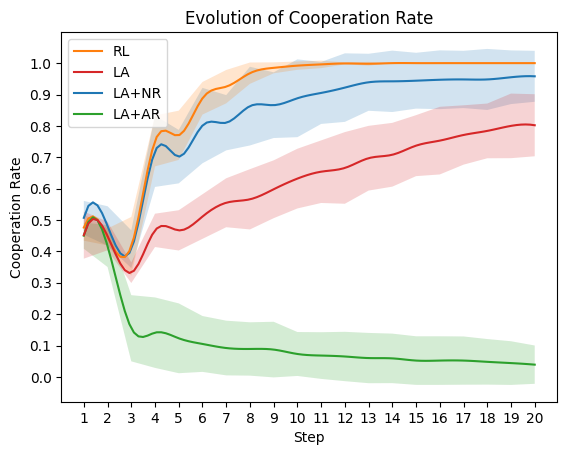

In [31]:
# plot network_C_ratio and c_ratio_per_steps_data.mean(axis=0) in the same plot
x = range(1, 21)
y = network_C_ratio.mean(axis=0)
print(y.mean())
f = interp1d(x, y, kind='cubic')
x_smooth = np.linspace(1, 20, 100)
y_smooth = f(x_smooth)
plt.plot(x_smooth, y_smooth, label='LA+NR')
std = network_C_ratio.std(axis=0)
# plt.plot(x, y, label='NR')
plt.fill_between(x, y-std, y+std, alpha=0.2)
print(f'NR: y: {y.mean()}')
for name in all_data_dict.keys():
    if 'C ratio per steps' in name:
        y = all_data_dict[name].mean(axis=0)
        print(f'{name}: y: {y.mean()}')
        f = interp1d(x, y, kind='cubic')
        x_smooth = np.linspace(1, 20, 100)
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=name.split('_')[0])
        std = all_data_dict[name].std(axis=0)
        # plt.plot(x, y, label=name.split('_')[0])
        # make the plot curved
        
        plt.fill_between(x, y-std, y+std, alpha=0.2)

# change the order of plots in the legend
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 3, 0, 2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')

# plt.legend()
plt.xlabel('Step')
plt.ylabel('Cooperation Rate')
plt.title(f'Evolution of Cooperation Rate', fontsize=12)
# make the x axis show integer only
plt.xticks(np.arange(1, 21, 1.0))
# make the y axis show 2 decimal places
plt.yticks(np.arange(0, 1.1, 0.1))
plt.savefig(os.path.join('figs/', f'C_ratio_evolution_curved.png'), dpi=500)
plt.show()

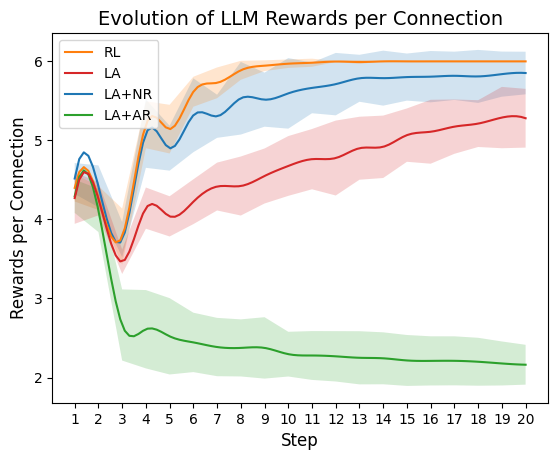

In [22]:
# plotting rewards per connection
x = range(1, 21)
y = network_rewards_per_connection.mean(axis=0)
std = network_rewards_per_connection.std(axis=0)
# plt.plot(x, y, label='NR')

f = interp1d(x, y, kind='cubic')
x_smooth = np.linspace(1, 20, 100)
y_smooth = f(x_smooth)
plt.plot(x_smooth, y_smooth, label='LA+NR')
plt.fill_between(x, y-std, y+std, alpha=0.2)
for name in all_data_dict.keys():
    if 'reward_per_connection' in name:
        all_data_dict[name] = np.array(all_data_dict[name])
        y = all_data_dict[name].mean(axis=0)
        f = interp1d(x, y, kind='cubic')
        x_smooth = np.linspace(1, 20, 100)
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=name.split('_')[0])
        std = all_data_dict[name].std(axis=0)
        # plt.plot(x, y, label=name.split('_')[0])
        plt.fill_between(x, y-std, y+std, alpha=0.2)

# change the order of plots in the legend
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 3, 0, 2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')
plt.xlabel('Step', fontsize=12)
plt.ylabel('Rewards per Connection', fontsize=12)
plt.title(f'Evolution of LLM Rewards per Connection', fontsize=14)
# make the x axis show integer only
plt.xticks(np.arange(1, 21, 1.0))
plt.savefig(os.path.join('figs/', f'Rewards_per_connection_evolution_curved.png'), dpi=500)
plt.show()

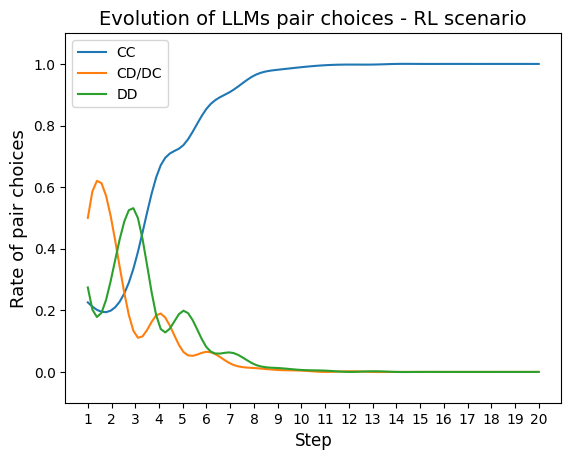

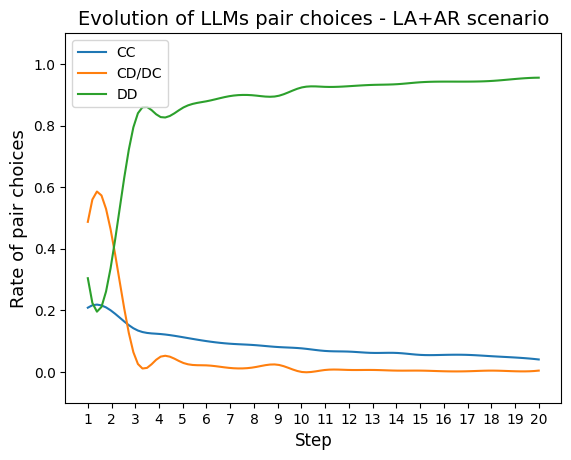

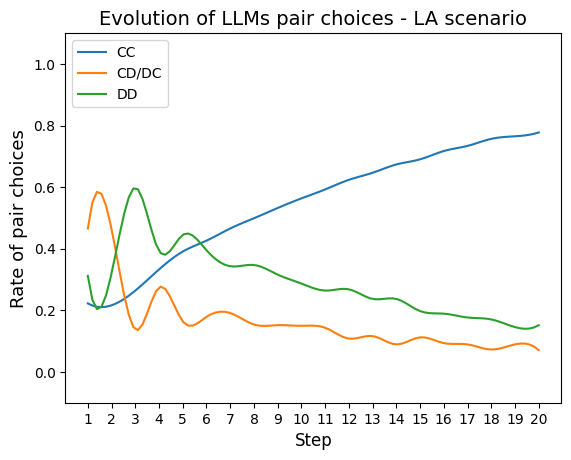

In [23]:
# plot pair actions for RL
scenarios = ['RL', 'LA+AR', 'LA']
for scenario in scenarios:
    pair_actions = all_data_dict[f'{scenario}_Pair actions']

    CC_list = []
    CD_list = []
    DC_list = []
    DD_list = []
    # CD_or_DC_list = []

    for i in range(np.shape(pair_actions)[0]):
        CC_list_tem = []
        CD_list_tem = []
        DC_list_tem = []
        DD_list_tem = []
        for j in range(np.shape(pair_actions)[1]):
            CC_list_tem.append(pair_actions[i,j]['CC'])
            CD_list_tem.append(pair_actions[i,j]['CD'])
            DC_list_tem.append(pair_actions[i,j]['DC'])
            DD_list_tem.append(pair_actions[i,j]['DD'])
            # CD_or_DC_list.append(pair_actions[i,j]['CD']+pair_actions[i,j]['DC'])
        CC_list.append(CC_list_tem)
        CD_list.append(CD_list_tem)
        DC_list.append(DC_list_tem)
        DD_list.append(DD_list_tem)

    x = np.arange(1, 21)

    total_number = np.sum(CC_list + CD_list + DC_list + DD_list, axis=0) / 10

    aggregated_line = np.mean(CD_list, axis=0) / total_number + np.mean(DC_list, axis=0) / total_number

    # plt.plot(x, np.mean(CC_list, axis=0) / total_number, label='CC')
    # # plt.plot(x, np.mean(CD_list, axis=0) / total_number, label='CD')
    # # plt.plot(x, np.mean(DC_list, axis=0) / total_number, label='DC')
    # plt.plot(x, aggregated_line, label='CD/DC')
    # plt.plot(x, np.mean(DD_list, axis=0) / total_number, label='DD')

    # make it smooth
    f = interp1d(x, np.mean(CC_list, axis=0) / total_number, kind='cubic')
    x_smooth = np.linspace(1, 20, 100)
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='CC')
    f = interp1d(x, aggregated_line, kind='cubic')
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='CD/DC')
    f = interp1d(x, np.mean(DD_list, axis=0) / total_number, kind='cubic')
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='DD')

    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper left')
    plt.xlabel('Step', fontsize=12)  
    plt.ylabel('Rate of pair choices', fontsize=13)
    plt.title(f'Evolution of LLMs pair choices - {scenario} scenario', fontsize=14)
    # make the x axis show integer only
    plt.xticks(np.arange(1, 21, 1.0))
    plt.savefig(os.path.join('figs/', f'pair_actions_{scenario}.png'), dpi=500)
    # save it in pdf format
    # plt.savefig(os.path.join('figs/', f'pair_actions_{scenario}.pdf'))
    plt.show()

In [11]:
# merge all four figs in the /figs folder
from PIL import Image
import os
    
scenarios = ['RL', 'LA', 'LA+NR', 'LA+AR']
images = [Image.open(os.path.join('figs/', f'pair_actions_{scenario}.png')) for scenario in scenarios]
widths, heights = zip(*(i.size for i in images))

# remove the white space around the images
images = [i.crop(i.getbbox()) for i in images]
# remove the space between the images
images = [i.crop((0, 0, i.size[0]-60, i.size[1])) for i in images]
# save the merged image to a file called 'merged.png'
total_width = max(widths) * 2 - 120
total_height = max(heights) * 2
new_im = Image.new('RGB', (total_width, total_height))

# top row
new_im.paste(images[0], (0, 0))  # RL
new_im.paste(images[1], (max(widths)-60, 0))  # NR

# bottom row
new_im.paste(images[2], (0, max(heights)))  # LA
new_im.paste(images[3], (max(widths)-60, max(heights)))  # AR

new_im.save('figs/merged_pair_actions.png', dpi=(500, 500))


In [12]:
# merge two figs horizontally
# one fig is C_ratio_evolution_curved.png and the other is merged_pair_actions.png
image1 = Image.open(os.path.join('figs/', 'C_ratio_evolution_curved.png'))
image2 = Image.open(os.path.join('figs/', 'merged_pair_actions.png'))

# remove the white space around the images
image1 = image1.crop(image1.getbbox())
image2 = image2.crop(image2.getbbox())

# remove the space between the images
image1 = image1.crop((0, 0, image1.size[0], image1.size[1]))
image2 = image2.crop((0, 0, image2.size[0], image2.size[1]))

# make the second image smaller
image2 = image2.resize((image2.size[0]//2, image2.size[1]//2))

# scale the first image vertically to be 1.1 times of previous height
image1 = image1.resize((int(image1.size[0]*1.15), int(image1.size[1]*1.15)))


total_width = image1.size[0] + image2.size[0] - 100
total_height = max(image1.size[1], image2.size[1])
new_im = Image.new('RGB', (total_width, total_height))

new_im.paste(image1, (0, 0))
# new_im.paste(image2, (image1.size[0]-50, 0))
# set the height to be in the middle of the first image
new_im.paste(image2, (image1.size[0]-100, (image1.size[1]-image2.size[1])//2))

# make the rest of the image white
# make the above and bottom of image2 white
new_im.paste((255, 255, 255), (image1.size[0]-100, 0, total_width, (image1.size[1]-image2.size[1])//2))
new_im.paste((255, 255, 255), (image1.size[0]-100, (image1.size[1]+image2.size[1])//2, total_width, image1.size[1]))

new_im.save('figs/merged_C_ratio_pair_actions.png', dpi=(500, 500))

In [13]:
# now, merge the c_ratio_evolution_curved.png and Rewards_per_connection_evolution_curved.png
image1 = Image.open(os.path.join('figs/', 'C_ratio_evolution_curved.png'))
image2 = Image.open(os.path.join('figs/', 'Rewards_per_connection_evolution_curved.png'))

# remove the white space around the images
image1 = image1.crop(image1.getbbox())
image2 = image2.crop(image2.getbbox())

# remove the space between the images
image1 = image1.crop((0, 0, image1.size[0], image1.size[1]))
image2 = image2.crop((0, 0, image2.size[0], image2.size[1]))

total_width = image1.size[0] + image2.size[0]
total_height = max(image1.size[1], image2.size[1])
new_im = Image.new('RGB', (total_width, total_height))

new_im.paste(image1, (0, 0))
new_im.paste(image2, (image1.size[0], 0))

new_im.save('figs/merged_C_ratio_Rewards_per_connection.png', dpi=(500, 500))
